<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/lectures/data_manipulation/sc_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numpy



<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/31/NumPy_logo_2020.svg/960px-NumPy_logo_2020.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20251223090330" width = "300" align="center"/>

> *"NumPy es al cómputo científico en Python lo que el álgebra lineal
> es a las matemáticas: el lenguaje base sobre el que todo lo demás se construye."*


## Introducción

[NumPy](https://numpy.org/) es la biblioteca fundamental para el cómputo numérico en Python. Su objeto central — el **array multidimensional** (`ndarray`) —  permite operar sobre vectores y matrices de forma eficiente, con una sintaxis mucho más limpia que las listas nativas de Python.

En este módulo aprenderás a:

- Crear y manipular arrays de una y múltiples dimensiones
- Realizar operaciones aritméticas, estadísticas y de álgebra lineal
- Visualizar datos numéricos con **matplotlib** de forma básica


## Python Lists vs Numpy Arrays

Antes de crear arrays, vale la pena entender por qué no basta con las listas de Python.



```python
64 + 8 * len (lst) + + len (lst) * 28
```                   

<img src="https://raw.githubusercontent.com/fralfaro/MAT281_2022/main/docs/lectures/data_manipulation/scientific_computing/images/list_structure.png" width = "500" align="center"/>

> Listas


```python
96 + n * 8 bytes
```

<img src="https://raw.githubusercontent.com/fralfaro/MAT281_2022/main/docs/lectures/data_manipulation/scientific_computing/images/array_structure.png" width = "500" align="center"/>

> Numpy arrays

In [2]:
import numpy as np 
import time
import sys

def arreglo_python(n):
    t1 = time.time()
    X = range(n)
    Y = range(n)
    Z = [X[i] + Y[i] for i in range(len(X)) ]
    return (time.time() - t1,sys.getsizeof(Z) )

def arreglo_numpy(n):
    t1 = time.time()
    X = np.arange(n)
    Y = np.arange(n)
    Z = X + Y
    return (time.time() - t1,sys.getsizeof(Z) )

In [3]:
# generar varios casos
for size_of_vec in [10,100,1000,10000,100000,1000000]:
    print(f"size of vector: {size_of_vec}")
    
    #list vs numpy
    t1, size1 = arreglo_python(size_of_vec)
    t2, size2 = arreglo_numpy(size_of_vec)
    
    # resultados
    print(f"python list -- time: {round(t1,8)} seg, size: {size1} bytes")
    print(f"numpy array -- time: {round(t2,8)} seg, size: {size2} bytes\n")

size of vector: 10
python list -- time: 8.82e-06 seg, size: 184 bytes
numpy array -- time: 8.13e-05 seg, size: 192 bytes

size of vector: 100
python list -- time: 1.86e-05 seg, size: 920 bytes
numpy array -- time: 1.931e-05 seg, size: 912 bytes

size of vector: 1000
python list -- time: 0.0001955 seg, size: 8856 bytes
numpy array -- time: 0.00024605 seg, size: 8112 bytes

size of vector: 10000
python list -- time: 0.00200582 seg, size: 85176 bytes
numpy array -- time: 0.00025821 seg, size: 80112 bytes

size of vector: 100000
python list -- time: 0.02143574 seg, size: 800984 bytes
numpy array -- time: 0.00159764 seg, size: 800112 bytes

size of vector: 1000000
python list -- time: 0.19724131 seg, size: 8448728 bytes
numpy array -- time: 0.01485848 seg, size: 8000112 bytes



> ✅ NumPy es ~2x más eficiente en memoria y hasta **50x más rápido**, para operaciones numéricas a gran escala.

## Objetos en Numpy

<img src="https://miro.medium.com/v2/resize:fit:1400/1*X0Dg7QfSYtWhSAu-afi8-g.png" width = "400" align="center"/>


El objeto principal es el `ndarray`. Puede ser 1D (vector), 2D (matriz) o nD (tensor).


In [4]:
import numpy as np

# Vector (1D)
v = np.array([1, 2, 3])

# Matriz (2D)
M = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

# Tensor (3D)
T = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])

print(f"vector: shape={v.shape}, ndim={v.ndim}, dtype={v.dtype}")
print(f"matriz: shape={M.shape}, ndim={M.ndim}, dtype={M.dtype}")
print(f"tensor: shape={T.shape}, ndim={T.ndim}, dtype={T.dtype}")

vector: shape=(3,), ndim=1, dtype=int64
matriz: shape=(2, 3), ndim=2, dtype=int64
tensor: shape=(2, 2, 2), ndim=3, dtype=int64


| Atributo     | Descripción                              | Ejemplo         |
|--------------|------------------------------------------|-----------------|
| `.shape`     | Dimensiones del array                    | `(3,)`, `(2,3)` |
| `.ndim`      | Número de dimensiones                    | `1`, `2`, `3`   |
| `.size`      | Total de elementos                       | `6`             |
| `.dtype`     | Tipo de datos                            | `int64`, `float64` |

### Arrays especiales


In [7]:
import numpy as np

print("zeros (3x3):")
print(np.zeros((3, 3)))

print("\nones (2x4):")
print(np.ones((2, 4)))

print("\nidentidad (3x3):")
print(np.eye(3))

print("\narange (0 a 10, paso 2):")
print(np.arange(0, 10, 2))

print("\nlinspace (0 a 1, 5 puntos):")
print(np.linspace(0, 1, 5))

np.random.seed(42)
print("\nuniform aleatorio (seed=42):")
print(np.random.uniform(0, 10, size=6))

zeros (3x3):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

ones (2x4):
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]

identidad (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

arange (0 a 10, paso 2):
[0 2 4 6 8]

linspace (0 a 1, 5 puntos):
[0.   0.25 0.5  0.75 1.  ]

uniform aleatorio (seed=42):
[3.74540119 9.50714306 7.31993942 5.98658484 1.5601864  1.5599452 ]


## Operaciones

### Aritméticas (element-wise)


### Operaciones aritméticas


In [8]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(a + b)   # [5 7 9]
print(a - b)   # [-3 -3 -3]
print(a * b)   # [4 10 18]
print(a / b)   # [0.25 0.4  0.5]
print(a ** 2)  # [1 4 9]

[5 7 9]
[-3 -3 -3]
[ 4 10 18]
[0.25 0.4  0.5 ]
[1 4 9]


> - `a * b` es multiplicación **elemento a elemento**, no producto matricial.
> - Para producto matricial usa `np.dot(A, B)` o el operador `@`.

### Comparación

In [9]:
a = np.array([1, 2, 3])
b = np.array([2, 2, 4])

print(a == b)   # [False  True False]
print(a > b)    # [False False False]
print(a <= b)   # [ True  True  True]

[False  True False]
[False False False]
[ True  True  True]



Los resultados son arrays booleanos — útiles para **filtrar** datos:

In [10]:
# Seleccionar elementos mayores a 2
print(a[a > 2])   # [3]

[3]


### Estadísticas

In [11]:
a = np.array([2, 4, 4, 4, 5, 5, 7, 9])

print(f"suma:    {np.sum(a)}")
print(f"media:   {np.mean(a):.2f}")
print(f"std:     {np.std(a):.2f}")
print(f"mínimo:  {np.min(a)}")
print(f"máximo:  {np.max(a)}")
print(f"mediana: {np.median(a)}")

suma:    40
media:   5.00
std:     2.00
mínimo:  2
máximo:  9
mediana: 4.5


## Indexación y Slicing 



In [14]:
# --- 1D ---
a = np.array([10, 20, 30, 40, 50])

print("\n--- vector 1D ---")
print(a)

print("\nprimer elemento (a[0]):")
print(a[0])

print("\núltimo elemento (a[-1]):")
print(a[-1])

print("\nslice a[1:4]:")
print(a[1:4])

print("\ncada dos elementos a[::2]:")
print(a[::2])

# --- 2D ---
M = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("\n--- matriz 2D ---")
print(M)

print("\nprimera fila M[0, :]:")
print(M[0, :])

print("\nsegunda columna M[:, 1]:")
print(M[:, 1])

print("\nelemento (fila 1, col 2) M[1, 2]:")
print(M[1, 2])

print("\nprimeras dos filas M[:2, :]:")
print(M[:2, :])

print("\ndiagonal M.diagonal():")
print(M.diagonal())


--- vector 1D ---
[10 20 30 40 50]

primer elemento (a[0]):
10

último elemento (a[-1]):
50

slice a[1:4]:
[20 30 40]

cada dos elementos a[::2]:
[10 30 50]

--- matriz 2D ---
[[1 2 3]
 [4 5 6]
 [7 8 9]]

primera fila M[0, :]:
[1 2 3]

segunda columna M[:, 1]:
[2 5 8]

elemento (fila 1, col 2) M[1, 2]:
6

primeras dos filas M[:2, :]:
[[1 2 3]
 [4 5 6]]

diagonal M.diagonal():
[1 5 9]


## Algebra Lineal

NumPy cubre las operaciones fundamentales del curso vía `np.linalg`:

In [16]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

# --- operaciones básicas ---
print("matriz A:")
print(A)

print("\ntranspuesta A.T:")
print(A.T)

print("\ndeterminante:")
print(round(np.linalg.det(A), 4))

print("\ninversa:")
print(np.linalg.inv(A))

print("\ntraza:")
print(np.trace(A))

# --- valores y vectores propios ---
print("\n--- eigendescomposición ---")
vals, vecs = np.linalg.eig(A)
print(f"eigenvalues:  {np.round(vals, 4)}")
print(f"eigenvectors:\n{np.round(vecs, 4)}")

# --- normas ---
print("\n--- normas ---")
print(f"norma frobenius:  {np.linalg.norm(A, 'fro'):.4f}")
print(f"norma espectral:  {np.linalg.norm(A, 2):.4f}")
print(f"rango:            {np.linalg.matrix_rank(A)}")

# --- descomposiciones ---
print("\n--- descomposición SVD ---")
U, S, Vt = np.linalg.svd(A)
print(f"U:\n{np.round(U, 4)}")
print(f"valores singulares: {np.round(S, 4)}")
print(f"Vt:\n{np.round(Vt, 4)}")

# --- sistema de ecuaciones Ax = b ---
print("\n--- sistema Ax = b ---")
b = np.array([5., 7.])
x = np.linalg.solve(A, b)
print(f"b:          {b}")
print(f"solución x: {np.round(x, 4)}")
print(f"verificación Ax: {np.round(A @ x, 4)}")

matriz A:
[[1 2]
 [3 4]]

transpuesta A.T:
[[1 3]
 [2 4]]

determinante:
-2.0

inversa:
[[-2.   1. ]
 [ 1.5 -0.5]]

traza:
5

--- eigendescomposición ---
eigenvalues:  [-0.3723  5.3723]
eigenvectors:
[[-0.8246 -0.416 ]
 [ 0.5658 -0.9094]]

--- normas ---
norma frobenius:  5.4772
norma espectral:  5.4650
rango:            2

--- descomposición SVD ---
U:
[[-0.4046 -0.9145]
 [-0.9145  0.4046]]
valores singulares: [5.465 0.366]
Vt:
[[-0.576  -0.8174]
 [ 0.8174 -0.576 ]]

--- sistema Ax = b ---
b:          [5. 7.]
solución x: [-3.  4.]
verificación Ax: [5. 7.]


## Broadcasting

Broadcasting permite operar entre arrays de **distinta forma** sin copiar datos.
La regla básica: NumPy "expande" el array más pequeño para que las formas sean compatibles.

<img src="https://raw.githubusercontent.com/fralfaro/MAT281_2022/main/docs/lectures/data_manipulation/scientific_computing/images/broad.png" width = "500" align="center"/>



In [17]:
import numpy as np

# --- escalar + vector ---
print("escalar + vector (np.arange(3) + 5):")
print(np.arange(3) + 5)

print("\nescalar * vector (np.arange(3) * 3):")
print(np.arange(3) * 3)

# --- matriz + vector (broadcasting por filas) ---
print("\n--- broadcasting por filas ---")
print("matriz ones(3,3) + arange(3):")
print(np.ones((3, 3)) + np.arange(3))

print("\nmatriz ones(3,3) * arange(3):")
print(np.ones((3, 3)) * np.arange(3))

# --- vector columna + vector fila → matriz ---
print("\n--- vector columna + vector fila ---")
col = np.arange(3).reshape((3, 1))
fil = np.arange(3)
print("columna:")
print(col)
print("\nfila:")
print(fil)
print("\nresultado col + fila:")
print(col + fil)

# --- comparaciones con broadcasting ---
print("\n--- comparaciones ---")
M = np.arange(9).reshape((3, 3))
print("matriz M:")
print(M)
print("\nM > 4:")
print(M > 4)
print("\nM[M > 4]  (filtrado):")
print(M[M > 4])

# --- operaciones entre matrices compatibles ---
print("\n--- shapes compatibles ---")
A = np.ones((3, 3)) * 10
b = np.array([1, 2, 3])
print("A (3x3):")
print(A)
print("\nb (3,):")
print(b)
print("\nA / b:")
print(A / b)

escalar + vector (np.arange(3) + 5):
[5 6 7]

escalar * vector (np.arange(3) * 3):
[0 3 6]

--- broadcasting por filas ---
matriz ones(3,3) + arange(3):
[[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]

matriz ones(3,3) * arange(3):
[[0. 1. 2.]
 [0. 1. 2.]
 [0. 1. 2.]]

--- vector columna + vector fila ---
columna:
[[0]
 [1]
 [2]]

fila:
[0 1 2]

resultado col + fila:
[[0 1 2]
 [1 2 3]
 [2 3 4]]

--- comparaciones ---
matriz M:
[[0 1 2]
 [3 4 5]
 [6 7 8]]

M > 4:
[[False False False]
 [False False  True]
 [ True  True  True]]

M[M > 4]  (filtrado):
[5 6 7 8]

--- shapes compatibles ---
A (3x3):
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]

b (3,):
[1 2 3]

A / b:
[[10.          5.          3.33333333]
 [10.          5.          3.33333333]
 [10.          5.          3.33333333]]


## Visualización con Matplotlib

<img src="https://numiqo.com/assets/tutorial/Diagram_Types.png" width = "500" align="center"/>

NumPy y Matplotlib trabajan de forma natural juntos: matplotlib opera directamente sobre arrays. Aquí los gráficos más útiles para explorar datos numéricos.



In [19]:
import numpy as np
import matplotlib.pyplot as plt



### Gráfico de línea

- Cuándo: evolución de una variable continua en el tiempo o sobre un eje ordenado.
- Ideal para funciones matemáticas, series de tiempo, señales.


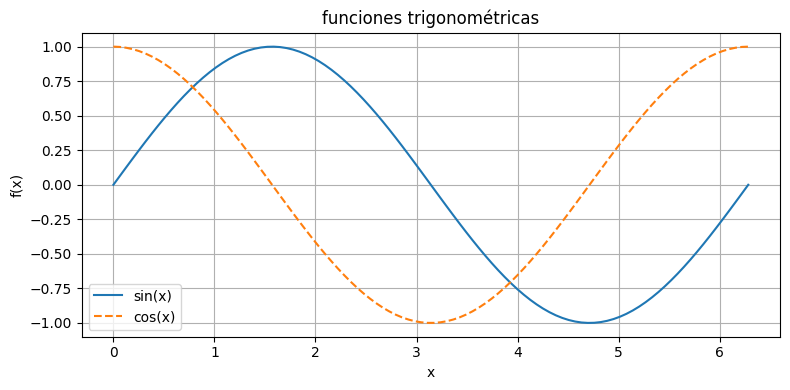

In [20]:
x = np.linspace(0, 2 * np.pi, 100)

plt.figure(figsize=(8, 4))
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)", linestyle="--")
plt.title("funciones trigonométricas")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Gráfico de dispersión 
- Cuándo: relación entre dos variables numéricas.
- Útil para detectar correlación, outliers o agrupaciones.

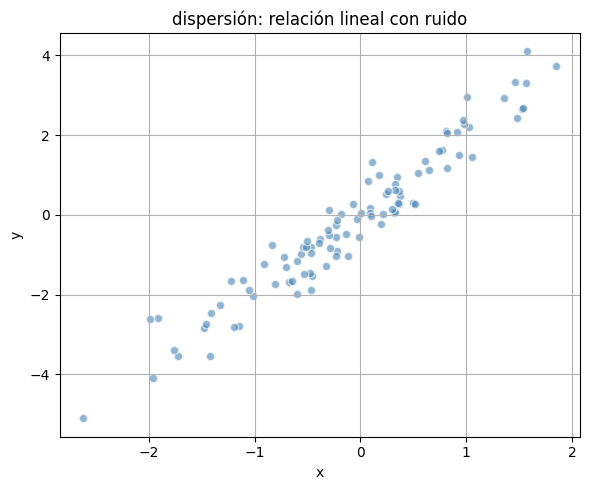

In [21]:
np.random.seed(42)
x = np.random.randn(100)
y = 2 * x + np.random.randn(100) * 0.5

plt.figure(figsize=(6, 5))
plt.scatter(x, y, alpha=0.6, color="steelblue", edgecolors="white")
plt.title("dispersión: relación lineal con ruido")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.tight_layout()
plt.show()

### Histograma

- Cuándo: distribución de una variable numérica.
- Muestra frecuencia, simetría, sesgo y presencia de outliers.

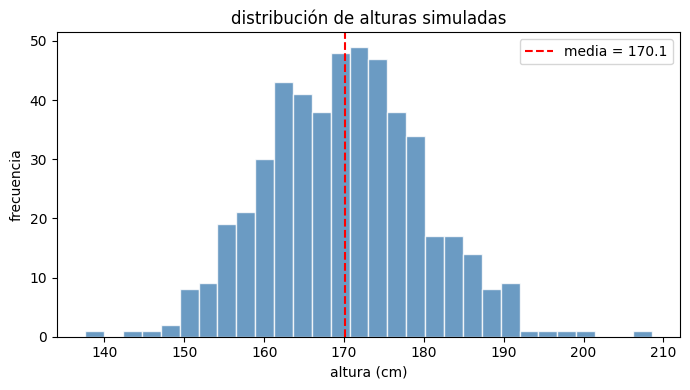

In [22]:
np.random.seed(42)
datos = np.random.normal(loc=170, scale=10, size=500)

plt.figure(figsize=(7, 4))
plt.hist(datos, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(np.mean(datos), color="red", linestyle="--",
            label=f"media = {np.mean(datos):.1f}")
plt.title("distribución de alturas simuladas")
plt.xlabel("altura (cm)")
plt.ylabel("frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

### Gráfico de barras

- Cuándo: comparar categorías o grupos discretos.
- Mejor que la línea cuando el eje x no tiene orden continuo.

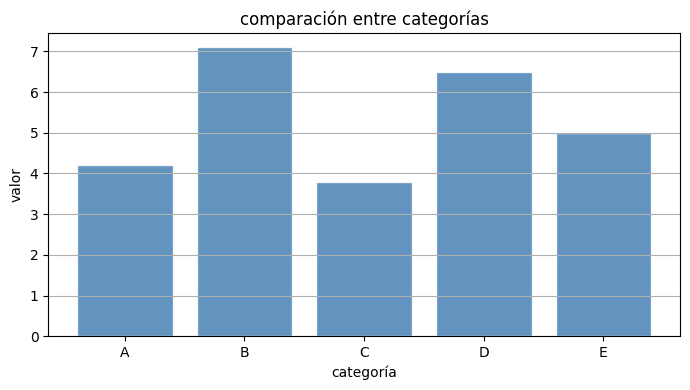

In [24]:
categorias = ["A", "B", "C", "D", "E"]
valores = np.array([4.2, 7.1, 3.8, 6.5, 5.0])

plt.figure(figsize=(7, 4))
plt.bar(categorias, valores, color="steelblue", edgecolor="white", alpha=0.85)
plt.title("comparación entre categorías")
plt.xlabel("categoría")
plt.ylabel("valor")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Boxplot

- Cuándo: resumir distribución y detectar outliers en uno o varios grupos.
- Muestra mediana, cuartiles y valores extremos de forma compacta.

/tmp/ipykernel_1307/1695828513.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=["G1", "G2", "G3", "G4"],


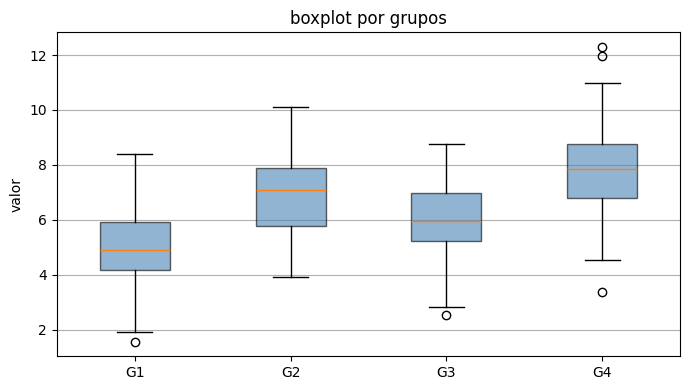

In [26]:
np.random.seed(7)
grupos = [np.random.normal(loc, 1.5, 100) for loc in [5, 7, 6, 8]]

plt.figure(figsize=(7, 4))
plt.boxplot(grupos, labels=["G1", "G2", "G3", "G4"],
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6))
plt.title("boxplot por grupos")
plt.ylabel("valor")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### Heatmap

- Cuándo: visualizar una matriz o tabla de valores numéricos.
- Útil para matrices de correlación, confusión o intensidades.

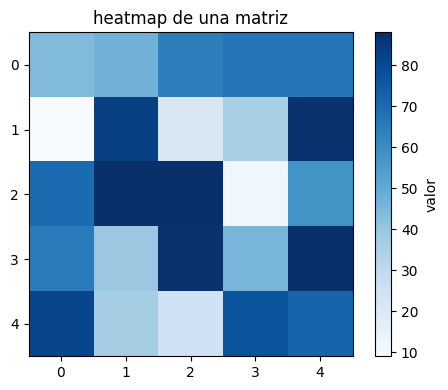

In [23]:
np.random.seed(0)
M = np.random.randint(0, 100, size=(5, 5))

plt.figure(figsize=(5, 4))
plt.imshow(M, cmap="Blues")
plt.colorbar(label="valor")
plt.title("heatmap de una matriz")
plt.tight_layout()
plt.show()

## Referencias

1. [Quickstart tutorial-numpy](https://docs.scipy.org/doc/numpy/user/quickstart.html)
2. [Quickstart tutorial-matplotlib](https://matplotlib.org/stable/tutorials/introductory/usage.html)
